In [1]:
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output, run_gds_jax
from mGST.low_level_jit import cost_function_jax_mps, cost_function_numba, cost_function_jax
from mGST.algorithm import run_mGST

from mGST.additional_fns import perturbed_target_init

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

# 2Q Emerald

## Setup

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import CZGate, RGate
import pickle

qubit_layouts = [[2,8], [4,10], [6,12], [15,23], [19,25], [21,27], [31,39], [30,35], [42,46], [44,48]]

gates = [QuantumCircuit(2, 0) for _ in range(7)]
gates[0].append(RGate(1e-9, 0), [0])
gates[1].append(RGate(0.5 * jnp.pi, 0), [0])
gates[2].append(RGate(0.5 * jnp.pi, 0), [1])
gates[3].append(RGate(0.5 * jnp.pi, jnp.pi / 2), [0])
gates[4].append(RGate(0.5 * jnp.pi, jnp.pi / 2), [1])
gates[5].append(RGate(0.5 * jnp.pi, 0), [0])
gates[5].append(RGate(0.5 * jnp.pi, 0), [1])
gates[6].append(CZGate(), [[0], [1]])
gate_labels = [
    "Idle",
    "Rx(pi/2):0",
    "Rx(pi/2):1",
    "Ry(pi/2):0",
    "Ry(pi/2):1",
    "Rx(pi/2)-Rx(pi/2):0-1",
    "CZ",
]

Q2_GST_EMERALD = GSTConfiguration(
    qubit_layouts=qubit_layouts,
    gate_set=gates,
    gate_labels = gate_labels,
    num_circuits=1000,
    shots=1000,
    rank=16,
    opt_method="GD",
    max_iterations = [140, 250],
    convergence_criteria=[4, 1e-4],
    parallel_execution = True,
    max_gates_per_batch = 35000
)

with open('emerald_2q_parallel_qubits_44__48.pkl', 'rb') as function:
    data = pickle.load(function)
    
X_true = data["X_true"]
E_true = data["E_true"]
rho_true = data["rho_true"]

K_target = data["K_target"]
X_target = data["X_target"]
E_target = data["E_target"]
rho_target = data["rho_target"]

# dimensions
dim = rho_true.shape[0]
num_povm = E_true.shape[0]
num_gates = X_true.shape[0]
bsize = 30 * dim
# Getting the values to be initialized
kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(X_target, E_target, rho_target, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax_target = povm_psd_2q_target.conj().transpose(0, 2, 1) @ povm_psd_2q_target
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_target, kraus_tensor_2q_target.conj()).reshape((num_gates, dim**2, dim**2))

rho_target_matrix = rho_target.reshape(dim, dim)
povm_target_matrices = E_target.reshape(num_povm, dim, dim)

jnp.allclose(state_psd_2q_target @ state_psd_2q_target.conj().T, rho_target_matrix), jnp.allclose(povm_jax_target, povm_target_matrices), jnp.allclose(superop_kraus_test, X_target)

INFO:2025-05-05 18:34:24,380:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-05-05 18:34:24,380 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-05-05 18:34:24,383:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [3]:
state_mgst_true = rho_true.reshape(-1)
povm_mgst_true = E_true.reshape(num_povm, -1)

kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true  = get_compressed_rep_from_mgst_output(X_true, povm_mgst_true, state_mgst_true, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax = povm_psd_2q_true.conj().transpose(0, 2, 1) @ povm_psd_2q_true
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_true, kraus_tensor_2q_true.conj()).reshape((num_gates, dim**2, dim**2))

target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]

jnp.allclose(state_psd_2q_true @ state_psd_2q_true.conj().T, rho_true), jnp.allclose(povm_jax, E_true), jnp.allclose(superop_kraus_test, X_true)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [4]:
from mGST.additional_fns import sampled_measurements, random_seq_design
from mGST.low_level_jit import contract_mps_all_povm

shots = 1000

N = 100  # Number of sequences
N_short = int(jnp.ceil(N / 2))
N_long = int(jnp.floor(N / 2))
meas_samples = 1e5  # Number of samples per sequences

# generate random numbers between 0 and $d^l - 1$
J = random_seq_design(num_gates, 1, 8, 14, N_short, N_long)
indices_list_2q = [indices[indices != -1] for indices in J]
# compute outcome probabilities
prob_matrix_exact = []
for indices in indices_list_2q:
    prob_matrix_exact.append(jnp.real(contract_mps_all_povm(kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true, indices)))
    
prob_matrix_exact = jnp.array(prob_matrix_exact).T
prob_matrix_2q_sampled = sampled_measurements(prob_matrix_exact, shots, seed=42)


In [ ]:
kraus_rank = dim**2
K_init_mgst = perturbed_target_init(X_target, kraus_rank, seed=42)
X_init_mgst = jnp.einsum("ijkl,ijnm -> iknlm", K_init_mgst, K_init_mgst.conj()).reshape((num_gates, dim**2, dim**2))
E_target_mgst = E_target.reshape(num_povm, -1)
rho_target_mgst = rho_target.reshape(-1)
init_mgst = [K_init_mgst, E_target_mgst, rho_target_mgst]

In [8]:
from mGST.utility_functions_comparisons import get_compressed_rep_mgst_cholesky
povm_psd_mgst, state_psd_mgst = get_compressed_rep_mgst_cholesky(E_target_mgst, rho_target_mgst)
kraus_tensor_2q_init = jnp.array(K_init_mgst)
povm_psd_2q_init = jnp.array(povm_psd_mgst)
state_psd_2q_init = jnp.array(state_psd_mgst)

## Testing Hessian performance

### State

In [21]:
cost_value_init = cost_function_jax_mps(kraus_tensor_2q_init, povm_psd_2q_target, state_psd_2q_target, indices_list_2q, prob_matrix_2q_sampled, jit=True)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 13 the new count changed to: 4
at iteration 19 the new count changed to: 5
at iteration 25 the new count changed to: 6
at iteration 31 the new count changed to: 7
at iteration 37 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15


In [23]:
# timing test for the hessian on the state
from mGST.algorithm import B_SFN_riem_Hess

updated_state = B_SFN_riem_Hess(
    K=kraus_tensor_2q_init,
    A=povm_psd_2q_target,
    B=state_psd_2q_target,
    y=prob_matrix_2q_sampled,
    J=indices_list_2q,
    d=num_gates,
    r=dim**2,
    n_povm=num_povm,
    lam=1e-3
)

test_cost_value = cost_function_jax_mps(kraus_tensor_2q_init, povm_psd_2q_target, updated_state, indices_list_2q, prob_matrix_2q_sampled, jit=True)

test_cost_value, cost_value_init, test_cost_value < cost_value_init


(Array(0.0037082, dtype=float64),
 Array(0.00375904, dtype=float64),
 Array(True, dtype=bool))

In [19]:
%timeit B_SFN_riem_Hess(K=kraus_tensor_2q_init, A=povm_psd_2q_target, B=state_psd_2q_target, y=prob_matrix_2q_sampled, J=indices_list_2q, d=num_gates, r=dim**2, n_povm=num_povm, lam=1e-3)

243 ms ± 17 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### POVM

In [64]:
from mGST.algorithm import A_SFN_riem_Hess

povm_test_np = np.array(povm_psd_2q_target)
state_test_np = np.array(state_psd_2q_target)

updated_povm = A_SFN_riem_Hess(
    K=kraus_tensor_2q_init,
    A=povm_test_np,
    B=state_test_np,
    y=prob_matrix_2q_sampled,
    J=indices_list_2q,
    d=num_gates,
    r=dim**2,
    n_povm=num_povm,
    lam=1e-3
)

cost_povm_updated = cost_function_jax_mps(kraus_tensor_2q_init, updated_povm, state_psd_2q_target, indices_list_2q, prob_matrix_2q_sampled, jit=True)

test_cost_value, cost_value_init, cost_povm_updated, type(updated_povm)

(Array(0.0037082, dtype=float64),
 Array(0.00375904, dtype=float64),
 Array(0.00340034, dtype=float64),
 numpy.ndarray)

In [66]:
%timeit A_SFN_riem_Hess(K=kraus_tensor_2q_init, A=povm_test_np, B=state_test_np, y=prob_matrix_2q_sampled, J=indices_list_2q,d=num_gates,r=dim**2,n_povm=num_povm,lam=1e-3)

747 ms ± 102 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## optimization

In [534]:
kraus_updated_2q_mgst, x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, cost_fn_history_2q_mgst = run_mGST(
    prob_matrix_2q_sampled, indices_list_2q, 0, num_gates, dim**2, 16, num_povm, bsize, shots,
    init = init_mgst,
    method = "GD",
    final_iter=250,
    target_rel_prec=1e-4,
    return_operators_list=False,
)

Starting mGST optimization...
 63%|██████▎   | 158/250 [03:57<02:18,  1.50s/it]
	 Convergence criterion satisfied
	 Final objective 2.2974296138232603e-05 in time 237.89s


In [94]:
# only the hessian on the state, no povm
kraus_updated_2q_unregularized_hessian_state, povm_updated_2q_unregularized_hessian_state, state_updated_2q_unregularized_hessian_state, cost_fn_history_2q_unregularized_hessian_state = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=30,
    use_hessian=True,
    regularized=False,
    return_operators_list=False,
    which_hessian=["state"])

iteration:  0
Using JAX power
Optimized step size for Povm: [29.00000001]
Using JAX power
Optimized step size for Kraus: [10.56738282]
cost:  0.003759040152925293
iteration:  1
Using JAX power
Optimized step size for Povm: [29.00000001]
Using JAX power
Optimized step size for Kraus: [23.81250001]
cost:  0.00282478992405807
iteration:  2
Using JAX power
Optimized step size for Povm: [25.00000001]
Using JAX power
Optimized step size for Kraus: [12.45751954]
cost:  0.002180353647391572
iteration:  3
Using JAX power
Optimized step size for Povm: [29.00000001]
Using JAX power
Optimized step size for Kraus: [16.73437501]
cost:  0.0016252203193696268
iteration:  4
Using JAX power
Optimized step size for Povm: [26.00000001]
Using JAX power
Optimized step size for Kraus: [11.96337892]
cost:  0.0012019756508726102
iteration:  5
Using JAX power
Optimized step size for Povm: [26.75000001]
Using JAX power
Optimized step size for Kraus: [16.76171876]
cost:  0.0009225037725395666
iteration:  6
Using 

In [90]:
# this is using the state AND povm's hessian
# Note: the mGST uses 200 line search iterations.
kraus_updated_2q_unregularized_hessian_povm, povm_updated_2q_unregularized_hessian_povm, state_updated_2q_unregularized_hessian_povm, cost_fn_history_2q_unregularized_hessian_povm = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=200, # the same as the value for the gradient descent in MGST
    use_hessian=True,
    regularized=False,
    return_operators_list=False)

iteration:  0
Using JAX power
Optimized step size for Kraus: [10.09336173]
cost:  0.003759040152925293
iteration:  1
Using JAX power
Optimized step size for Kraus: [21.95137189]
cost:  0.0028075430034988523
iteration:  2
Using JAX power
Optimized step size for Kraus: [15.7060547]
cost:  0.0021092836532920264
iteration:  3
Using JAX power
Optimized step size for Kraus: [13.28623282]
cost:  0.0016081707824458769
iteration:  4
Using JAX power
Optimized step size for Kraus: [14.04150392]
cost:  0.0012551039101918388
iteration:  5
Using JAX power
Optimized step size for Kraus: [13.2551711]
cost:  0.0009929824349362492
iteration:  6
Using JAX power
Optimized step size for Kraus: [15.43959728]
cost:  0.0007971690147136532
iteration:  7
Using JAX power
Optimized step size for Kraus: [12.43457032]
cost:  0.0006516547034271801
iteration:  8
Using JAX power
Optimized step size for Kraus: [19.89961407]
cost:  0.0005516658706487852
iteration:  9
Using JAX power
Optimized step size for Kraus: [11.01

In [92]:
from mGST.utility_functions_comparisons import check_kraus_tensor_is_isometry
[check_kraus_tensor_is_isometry(kraus_test) for kraus_test in kraus_updated_2q_unregularized_hessian_povm]

[Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool)]

In [525]:
kraus_updated_2q_all_gds, povm_updated_2q_all_gds, state_updated_2q_all_gds, cost_fn_history_2q_all_gds = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=jnp.array(povm_psd_mgst),
    state_psd=jnp.array(state_psd_mgst),
    # povm_psd=povm_psd_2q_target,
    # state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=200, # the same as the value for the gradient descent in MGST
    regularized=False,
    return_operators_list=False,
    metric="canonical",
    which_hessian=[])

iteration:  0
Using JAX power
Optimized step size for Povm: [17.08760235]
Using JAX power
Optimized step size for Kraus: [5.32509532]
Using JAX power
Optimized step size for State: [6.8546922]
cost:  0.0037590401529252865
iteration:  1
Using JAX power
Optimized step size for Povm: [16.93828829]
Using JAX power
Optimized step size for Kraus: [11.24774688]
Using JAX power
Optimized step size for State: [5.87119376]
cost:  0.002880107621328813
iteration:  2
Using JAX power
Optimized step size for Povm: [12.48311017]
Using JAX power
Optimized step size for Kraus: [5.8634254]
Using JAX power
Optimized step size for State: [7.60518048]
cost:  0.0024334794568048102
iteration:  3
Using JAX power
Optimized step size for Povm: [16.4041086]
Using JAX power
Optimized step size for Kraus: [8.89048087]
Using JAX power
Optimized step size for State: [10.0527461]
cost:  0.00207758506558004
iteration:  4
Using JAX power
Optimized step size for Povm: [11.9249047]
Using JAX power
Optimized step size for 

In [529]:
kraus_updated_2q_all_gds_euclidean, povm_updated_2q_all_gds_euclidean, state_updated_2q_all_gds_euclidean, cost_fn_history_2q_all_gds_euclidean = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=jnp.array(povm_psd_mgst),
    state_psd=jnp.array(state_psd_mgst),
    # povm_psd=povm_psd_2q_target,
    # state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=200, # the same as the value for the gradient descent in MGST
    regularized=False,
    return_operators_list=False,
    metric="euclidean",
    which_hessian=[])

iteration:  0
Using JAX power
Optimized step size for Povm: [17.08760235]
Using JAX power
Optimized step size for Kraus: [5.32509532]
Using JAX power
Optimized step size for State: [6.8546922]
cost:  0.0037590401529252865
iteration:  1
Using JAX power
Optimized step size for Povm: [16.93828829]
Using JAX power
Optimized step size for Kraus: [11.24774688]
Using JAX power
Optimized step size for State: [5.87119376]
cost:  0.002880107621328813
iteration:  2
Using JAX power
Optimized step size for Povm: [12.48311017]
Using JAX power
Optimized step size for Kraus: [5.8634254]
Using JAX power
Optimized step size for State: [7.60518048]
cost:  0.0024334794568048102
iteration:  3
Using JAX power
Optimized step size for Povm: [16.4041086]
Using JAX power
Optimized step size for Kraus: [8.89048087]
Using JAX power
Optimized step size for State: [10.0527461]
cost:  0.00207758506558004
iteration:  4
Using JAX power
Optimized step size for Povm: [11.9249047]
Using JAX power
Optimized step size for 

In [649]:
kraus_updated_2q_hessian_povm_state_no_memory_canonical, povm_updated_2q_hessian_povm_state_no_memory_canonical, state_updated_2q_hessian_povm_state_no_memory_canonical, cost_fn_history_hessian_povm_state_no_memory_canonical = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=jnp.array(povm_psd_mgst),
    state_psd=jnp.array(state_psd_mgst),
    # povm_psd=povm_psd_2q_target,
    # state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=200, # the same as the value for the gradient descent in MGST
    use_hessian=True,
    regularized=False,
    return_operators_list=False,
    metric="canonical",)

iteration:  0
Using JAX power
Optimized step size for Kraus: [9.41572735]
cost:  0.0037590401529252865
iteration:  1
Using JAX power
Optimized step size for Kraus: [18.98301017]
cost:  0.0028788008157345562
iteration:  2
Using JAX power
Optimized step size for Kraus: [20.2918922]
cost:  0.0023768517651785647
iteration:  3
Using JAX power
Optimized step size for Kraus: [10.61757579]
cost:  0.001970979773578613
iteration:  4
Using JAX power
Optimized step size for Kraus: [15.44209454]
cost:  0.0017239050089014763
iteration:  5
Using JAX power
Optimized step size for Kraus: [10.99941173]
cost:  0.0015464862890845767
iteration:  6
Using JAX power
Optimized step size for Kraus: [15.48602814]
cost:  0.0014130804373069911
iteration:  7
Using JAX power
Optimized step size for Kraus: [10.4171922]
cost:  0.0012946570038065552
iteration:  8
Using JAX power
Optimized step size for Kraus: [18.50239728]
cost:  0.0011984901484230037
iteration:  9
Using JAX power
Optimized step size for Kraus: [9.1273

In [647]:
kraus_updated_hessian_povm_state_no_memory_euclidean, povm_updated_hessian_povm_state_no_memory_euclidean, state_updated_hessian_povm_state_no_memory_euclidean, cost_fn_history_hessian_povm_state_no_memory_euclidean = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=jnp.array(povm_psd_mgst),
    state_psd=jnp.array(state_psd_mgst),
    # povm_psd=povm_psd_2q_target,
    # state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=200, # the same as the value for the gradient descent in MGST
    use_hessian=True,
    regularized=False,
    return_operators_list=False,
    metric="euclidean")

iteration:  0
Using JAX power
Optimized step size for Kraus: [20.18662345]
cost:  0.0037590401529252865
iteration:  1
Using JAX power
Optimized step size for Kraus: [43.90615001]
cost:  0.002807543414080734
iteration:  2
Using JAX power
Optimized step size for Kraus: [31.40889142]
cost:  0.0021092544411348466
iteration:  3
Using JAX power
Optimized step size for Kraus: [26.57451876]
cost:  0.001608153601695734
iteration:  4
Using JAX power
Optimized step size for Kraus: [28.0808547]
cost:  0.001255092407100666
iteration:  5
Using JAX power
Optimized step size for Kraus: [26.51289532]
cost:  0.000992976363700429
iteration:  6
Using JAX power
Optimized step size for Kraus: [30.87520001]
cost:  0.0007971617508337712
iteration:  7
Using JAX power
Optimized step size for Kraus: [24.87162618]
cost:  0.0006516532270379975
iteration:  8
Using JAX power
Optimized step size for Kraus: [39.79154806]
cost:  0.0005516653893110473
iteration:  9
Using JAX power
Optimized step size for Kraus: [22.0229

In [655]:
# I can also calculate what is the L(p_sampled, p_exact)
from mGST.utility_functions_comparisons import calculate_finite_sampling_error
probability_distance_sampled = calculate_finite_sampling_error(prob_matrix_exact, prob_matrix_2q_sampled)
probability_distance_sampled

Array(0.00015064, dtype=float64)

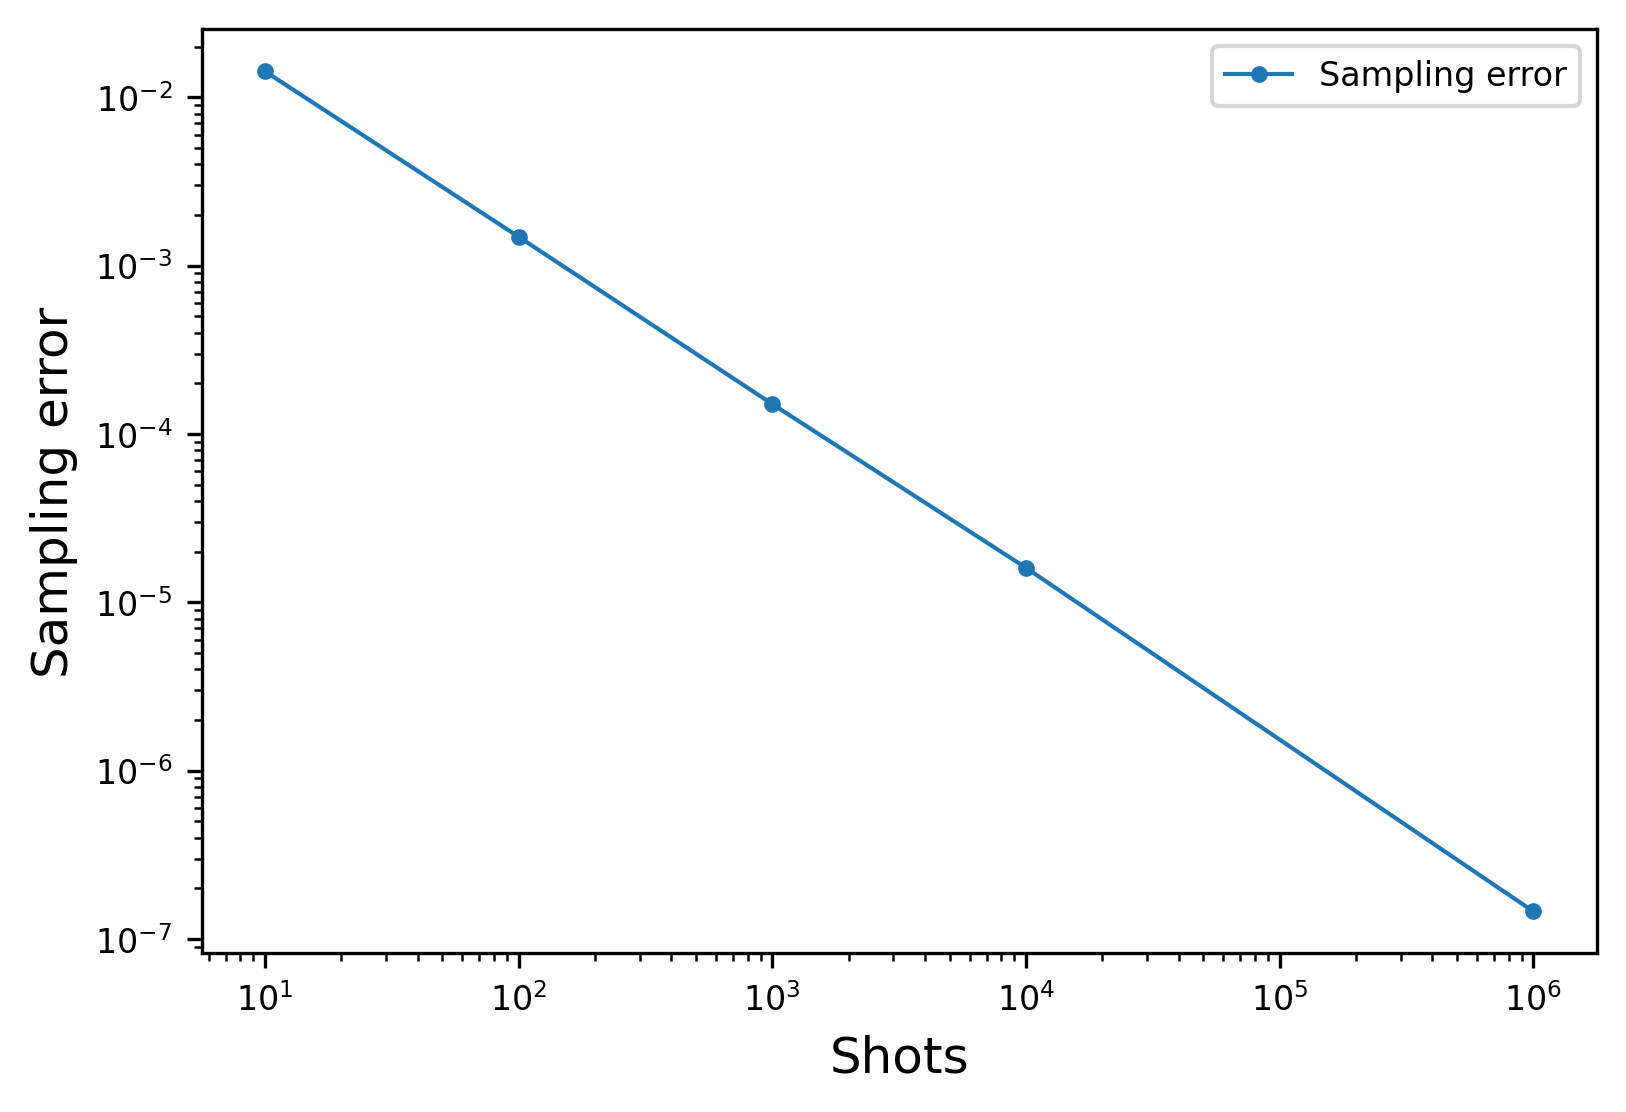

In [ ]:
sampling_error_vs_shots = []
shots_values = []
for shots_exponent in [1, 2, 3, 4, 6]:
    shots_test = 10**shots_exponent
    shots_values.append(shots_test)
    prob_matrix_2q_sampled_test = sampled_measurements(prob_matrix_exact, shots_test)   
    error = calculate_finite_sampling_error(prob_matrix_exact, prob_matrix_2q_sampled_test)
    sampling_error_vs_shots.append(error)
    
plt.figure(figsize=(6, 4), dpi=300)

plt.loglog(shots_values, sampling_error_vs_shots, marker="o", linestyle="-", linewidth=1, markersize=3, label="Sampling error")

plt.xlabel("Shots", fontsize=12)
plt.ylabel("Sampling error", fontsize=12)
plt.legend()

## Plotting

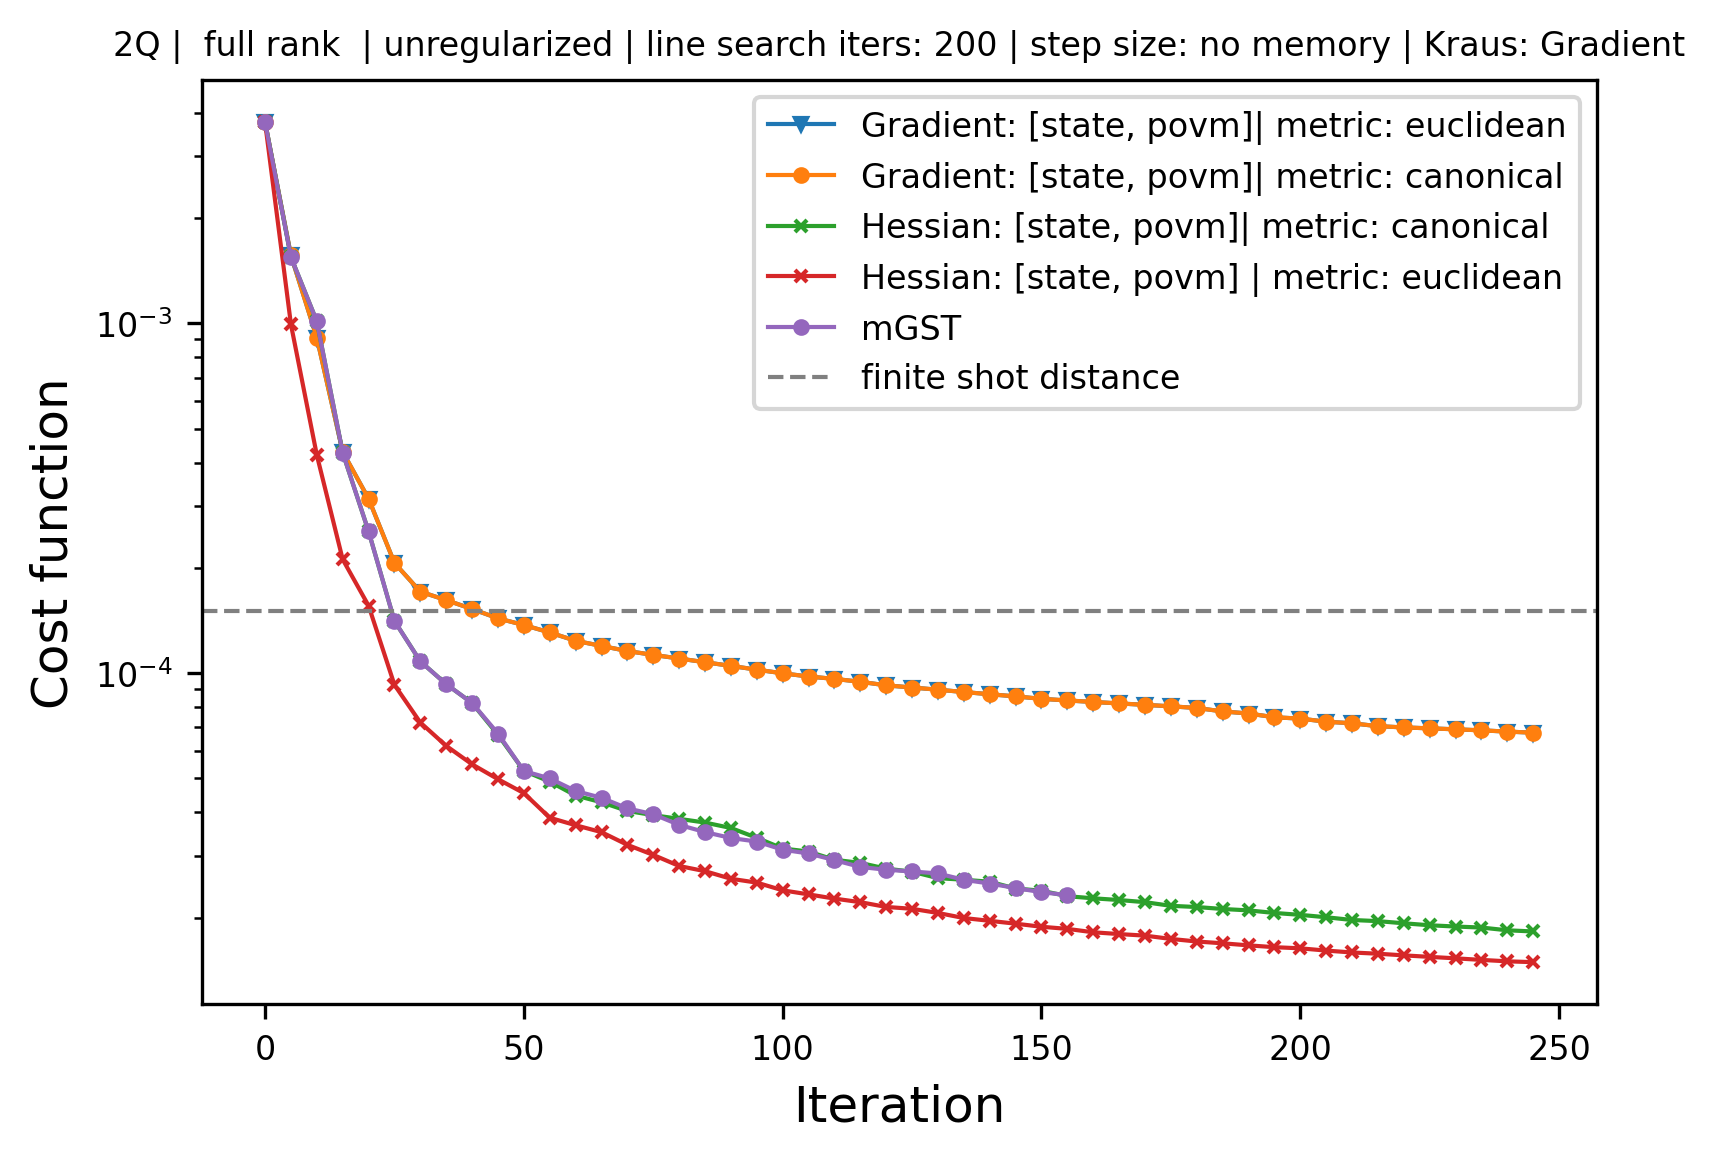

In [652]:
plot_step = 5
max_idx_data = -1

plt.figure(figsize=(6, 4), dpi=300)

# plt.semilogy(range(0, len(cost_fn_history_2q_all_gds[:max_idx_data]), plot_step), cost_fn_history_2q_all_gds[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Hessian: [] | step size: non memory | line search iters: 30")

# plt.semilogy(range(0, len(cost_fn_history_2q_unregularized_hessian_state[:max_idx_data]), plot_step), cost_fn_history_2q_unregularized_hessian_state[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Hessian: [state] | step size: no memory | line search iters: 30")

# plt.semilogy(range(0, len(cost_fn_history_2q_unregularized_hessian_povm[:max_idx_data]), plot_step), cost_fn_history_2q_unregularized_hessian_povm[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Hessian: [state, povm] | step size: memory | line search iters: 200")

plt.semilogy(range(0, len(cost_fn_history_2q_all_gds_euclidean[:max_idx_data]), plot_step), cost_fn_history_2q_all_gds_euclidean[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Gradient: [state, povm]| metric: euclidean")

plt.semilogy(range(0, len(cost_fn_history_2q_all_gds[:max_idx_data]), plot_step), cost_fn_history_2q_all_gds[:max_idx_data:plot_step], marker="o", linestyle="-", linewidth=1, markersize=3, label="Gradient: [state, povm]| metric: canonical")

plt.semilogy(range(0, len(cost_fn_history_hessian_povm_state_no_memory_canonical[:max_idx_data]), plot_step), cost_fn_history_hessian_povm_state_no_memory_canonical[:max_idx_data:plot_step], marker="x", linestyle="-", linewidth=1, markersize=3, label="Hessian: [state, povm]| metric: canonical")

plt.semilogy(range(0, len(cost_fn_history_hessian_povm_state_no_memory_euclidean
[:max_idx_data]), plot_step), cost_fn_history_hessian_povm_state_no_memory_euclidean
[:max_idx_data:plot_step], marker="x", linestyle="-", linewidth=1, markersize=3, label="Hessian: [state, povm] | metric: euclidean")

plt.semilogy(range(0, len(cost_fn_history_2q_mgst[:max_idx_data]), plot_step), cost_fn_history_2q_mgst[:max_idx_data:plot_step], marker="o", linestyle="-", linewidth=1, markersize=3, label="mGST")

plt.axhline(y=probability_distance_sampled, color='grey', linestyle='--', linewidth=1, label="finite shot distance")

plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q |  full rank  | unregularized | line search iters: 200 | step size: no memory | Kraus: Gradient")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

In [329]:
max_idx_data = 5
jnp.allclose(cost_fn_history_2q_mgst[max_idx_data], cost_fn_history_hessian_povm_state_no_memory_canonical[max_idx_data]), cost_fn_history_2q_mgst[max_idx_data], cost_fn_history_hessian_povm_state_no_memory_canonical[max_idx_data]

(Array(False, dtype=bool),
 Array(0.00154643, dtype=float64),
 Array(0.00154646, dtype=float64))

# Why are they not exactly the same?

Check the Hessian we are producing on one step of MGST vs one step of JAX

In [538]:
from mGST.utility_functions_comparisons import get_compressed_rep_mgst_cholesky, update_povm_via_saddle_free_newton, update_state_via_saddle_free_newton
# K_init_mgst
povm_psd_mgst, state_psd_mgst = get_compressed_rep_mgst_cholesky(E_target_mgst, rho_target_mgst)

In [539]:
jnp.allclose(K_init_mgst, kraus_tensor_2q_init)

Array(True, dtype=bool)

In [544]:
from mGST.utility_functions_comparisons import state_from_psd, povm_from_psd

# calculate the new povm factor
new_povm_psd_mgst = update_povm_via_saddle_free_newton(
        kraus_tensor=K_init_mgst,
        povm_psd=povm_psd_mgst,
        state_psd=state_psd_mgst,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
    )

new_povm_psd_jax = update_povm_via_saddle_free_newton(
        kraus_tensor=kraus_tensor_2q_init,
        povm_psd=povm_psd_mgst,
        state_psd=state_psd_mgst,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
    )

new_state_psd_mgst = update_state_via_saddle_free_newton(
        kraus_tensor=K_init_mgst,
        povm_psd=new_povm_psd_mgst,
        state_psd=state_psd_mgst,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
    )

new_state_psd_jax = update_state_via_saddle_free_newton(
        kraus_tensor=kraus_tensor_2q_init,
        povm_psd=new_povm_psd_jax,
        state_psd=state_psd_mgst,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
    )

print(jnp.allclose(new_povm_psd_mgst, new_povm_psd_jax), jnp.allclose(new_state_psd_mgst, new_state_psd_jax))

povm_test_mgst = povm_from_psd(new_povm_psd_mgst)
povm_test_jax = povm_from_psd(new_povm_psd_jax)

state_test_mgst = state_from_psd(new_state_psd_mgst)
state_test_jax = state_from_psd(new_state_psd_jax)

jnp.allclose(povm_test_mgst, povm_test_jax), jnp.allclose(state_test_mgst, state_test_jax)


True True


(Array(True, dtype=bool), Array(True, dtype=bool))

In [560]:
# testing when they deviate and why deviate
kraus_updated_test_mgst, x_updated_test_mgst, povm_updated_test_mgst, state_updated_test_mgst, cost_fn_updated_test_mgst = run_mGST(
    prob_matrix_2q_sampled, indices_list_2q, 0, num_gates, dim**2, 16, num_povm, bsize, shots,
    init = init_mgst,
    method = "GD",
    final_iter=5,
    target_rel_prec=1e-4,
    return_operators_list=True,
)

Starting mGST optimization...
100%|██████████| 5/5 [00:07<00:00,  1.41s/it]
	 Convergence criterion not satisfied, try increasing max_iter or using new initializations.
	 Final objective 0.0015464862890845728 in time 7.08s


In [611]:
kraus_updated_test_jax, povm_updated_test_jax, state_updated_test_jax, cost_fn_updated_test_jax = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_mgst, #povm_psd_2q_target,
    state_psd=state_psd_mgst, #state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=5, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=200, # the same as the value for the gradient descent in MGST
    use_hessian=True,
    regularized=False,
    return_operators_list=True)

iteration:  0
Using JAX power
Optimized step size for Kraus: [9.41572735]
cost:  0.0037590401529252865
iteration:  1
Using JAX power
Optimized step size for Kraus: [18.98301017]
cost:  0.002878800815734556
iteration:  2
Using JAX power
Optimized step size for Kraus: [20.2920922]
cost:  0.002376851765178556
iteration:  3
Using JAX power
Optimized step size for Kraus: [10.61747579]
cost:  0.001970979325770246
iteration:  4
Using JAX power
Optimized step size for Kraus: [15.44150626]
cost:  0.001723903215947697


In [620]:
from mGST.utility_functions_comparisons import kraus_from_psd

idx_test = 2

k_init_test_mgst = kraus_updated_test_mgst[idx_test]  
k_full_init_test_mgst = x_updated_test_mgst[idx_test] #kraus_from_psd(k_init_test_mgst)

povm_full_init_test_mgst = povm_updated_test_mgst[idx_test]
state_full_init_test_mgst = state_updated_test_mgst[idx_test]

_, povm_init_test_mgst, state_init_test_mgst = get_compressed_rep_from_mgst_output(k_full_init_test_mgst, povm_full_init_test_mgst, state_full_init_test_mgst, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

k_init_test_jax = kraus_updated_test_jax[idx_test]
povm_init_test_jax = povm_updated_test_jax[idx_test]
state_init_test_jax = state_updated_test_jax[idx_test]

inital_value_mgst_second_test = cost_function_numba(k_init_test_mgst, povm_full_init_test_mgst, state_full_init_test_mgst, indices_list_2q, prob_matrix_2q_sampled)

initial_value_mgst = cost_function_jax_mps(k_init_test_mgst, povm_init_test_mgst, state_init_test_mgst, indices_list_2q, prob_matrix_2q_sampled, jit=True)

initial_value_jax = cost_function_jax_mps(k_init_test_jax, povm_init_test_jax, state_init_test_jax, indices_list_2q, prob_matrix_2q_sampled, jit=True)
print(jnp.allclose(initial_value_mgst, initial_value_jax))
print(jnp.allclose(inital_value_mgst_second_test, initial_value_jax))

True
True


In [621]:
povm_test_mgst = povm_from_psd(povm_init_test_mgst) # povm_full_init_test_mgst
povm_test_jax = povm_from_psd(povm_init_test_jax) 


jnp.allclose(povm_test_mgst, povm_test_jax), jnp.allclose(povm_full_init_test_mgst.reshape(num_povm, dim, dim), povm_test_mgst)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [622]:
state_test_mgst = state_from_psd(state_init_test_mgst) # state_full_init_test_mgst
state_test_jax = state_from_psd(state_init_test_jax)

jnp.allclose(state_test_mgst, state_test_jax), jnp.allclose(state_full_init_test_mgst.reshape(dim, dim), state_test_mgst), jnp.allclose(state_full_init_test_mgst.reshape(dim, dim), state_test_jax)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [623]:
kraus_test_mgst = kraus_from_psd(k_init_test_mgst) # k_full_init_test_mgst
kraus_test_jax = kraus_from_psd(k_init_test_jax)

jnp.allclose(kraus_test_mgst, kraus_test_jax), jnp.allclose(k_full_init_test_mgst.reshape(num_gates, dim, dim, dim, dim), kraus_test_mgst), jnp.allclose(k_init_test_mgst, k_init_test_jax)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [629]:
# now for the kraus tensor.
from mGST.algorithm import gd
from mGST.utility_functions_comparisons import _update_tensor_via_gradient

fixed_gates = np.array([(f"G%i" % i in []) for i in range(num_gates)])
fixed_gates

step_size = 1e-8

rho_target_mgst_perturbed = state_psd_mgst @ state_psd_mgst.conj().T
# K_init_mgst, E_target_mgst, rho_target_mgst
new_kraus_tensor_mgst = gd(
    k_init_test_mgst, povm_full_init_test_mgst, state_full_init_test_mgst, prob_matrix_2q_sampled, indices_list_2q,
    d=num_gates, r=dim**2, rK=dim**2, ls="COBYLA", fixed_gates=fixed_gates, optimize_step=True, use_jax=False, step_size=step_size,
)

new_kraus_tensor_jax, _  = _update_tensor_via_gradient("kraus", k_init_test_jax, povm_init_test_jax, state_init_test_jax, indices_list_2q, prob_matrix_2q_sampled, ls_method="COBYLA", ls_max_iter=200, initial_step=step_size, metric="canonical", optimize_step=True)


kraus_test_mgst = kraus_from_psd(new_kraus_tensor_mgst)
kraus_test_jax = kraus_from_psd(new_kraus_tensor_jax)

jnp.allclose(new_kraus_tensor_mgst, new_kraus_tensor_jax), jnp.allclose(kraus_test_mgst, kraus_test_jax)


Using JAX power
Optimized step size for Kraus: [9.34502657]


(Array(True, dtype=bool), Array(True, dtype=bool))

In [662]:
# Let's check if the euclidean gradient is different
from mGST.algorithm import dK
from mGST.low_level_jit import gradient_k_mps_jit

kraus_gradient_mgst = dK(
    X=np.array(k_full_init_test_mgst), K=k_init_test_mgst, E=povm_full_init_test_mgst, rho=state_full_init_test_mgst, y=prob_matrix_2q_sampled, J=indices_list_2q,
    d=num_gates, r=dim**2, rK=dim**2
)

kraus_gradient_jax = gradient_k_mps_jit(
    k_init_test_jax, povm_init_test_jax, state_init_test_jax, indices_list_2q, prob_matrix_2q_sampled
)

jnp.allclose(kraus_gradient_mgst, kraus_gradient_jax/2)

Using JAX power


Array(True, dtype=bool)

In [644]:
from mGST.utility_functions_comparisons import euclidean_gradients_to_stiefel
from mGST.algorithm import tangent_proj

def kraus_euclidean_gradient_to_riemannian(kraus_euclidean_gradient: jnp.ndarray, kraus_tensor: jnp.ndarray)-> jnp.ndarray:
    """Convert the Kraus euclidean gradient to the riemannian gradient on the tangent space at the kraus tensor point in the manifold
    
    Args:
        kraus_euclidean_gradient: The euclidean gradient of the cost function wrt to the kraus tensor.
            Should be of dimensions (num_gates, kraus_rank, dim_out, dim_in)
        kraus_tensor: The kraus tensor defining the tangent space.
            Should be of dimensions (num_gates, kraus_rank, dim_out, dim_in)
    Returns:
        The riemannian gradient of the cost function wrt to the kraus tensor.
    """
    num_gates, kraus_rank, dim, dim = kraus_euclidean_gradient.shape
    n = kraus_rank * dim
    p = dim
    riemannian_gradient = np.zeros((num_gates, n, p)).astype(np.complex128)
    for k in np.where(~fixed_gates)[0]:
        # derivative
        z = kraus_euclidean_gradient[k].reshape(n, p)
        x = kraus_tensor[k].reshape(n, p)
        # Riem. gradient taken from conjugate derivative
        # so here we are implicitely getting the conjugate
        rGrad = z.conj() - x @ z.T @ x
        riemannian_gradient[k] = rGrad
        
    riemannian_gradient =  tangent_proj(kraus_tensor, riemannian_gradient, num_gates, kraus_rank)
    return riemannian_gradient
        
    
riemannian_gradient_mgst = kraus_euclidean_gradient_to_riemannian(kraus_gradient_mgst, k_init_test_mgst)

riemannian_gradient_jax, kraus_isometry_jax = euclidean_gradients_to_stiefel(
    gradient_tensor=kraus_gradient_jax.conj()/2,
    operator_tensor=k_init_test_jax, operator_type="kraus", metric="canonical",
)

jnp.allclose(riemannian_gradient_mgst, riemannian_gradient_jax)

Array(True, dtype=bool)

In [645]:
# the next thing to check is if the geodesic update is the same and if the optimization give the same results
from mGST.optimization import update_K_geodesic
from mGST.utility_functions_comparisons import _update_isometry_and_back_to_tensor

step_size = 1-8

kraus_updated_mgst = update_K_geodesic(k_init_test_mgst, riemannian_gradient_mgst, a=step_size)
kraus_updated_jax = _update_isometry_and_back_to_tensor(
    step_size=step_size, isometries=kraus_isometry_jax, riemannian_gradients=riemannian_gradient_jax,
    tensor_shape=k_init_test_jax.shape, operator_type="kraus", use_geodesic=True)

jnp.allclose(kraus_updated_mgst, kraus_updated_jax)

Array(True, dtype=bool)

In [646]:
# so is only the optimization part that is different?
from scipy.optimize import minimize
from mGST.optimization import lineobjf_isom_geodesic
from mGST.utility_functions_comparisons import cost_function_from_updated_operator

init_step = 1e-8
max_iters_ls = 200
# result from MGST
optimization_result_mgst = minimize(lineobjf_isom_geodesic, init_step, args=(riemannian_gradient_mgst, k_init_test_mgst, povm_full_init_test_mgst, state_full_init_test_mgst, indices_list_2q, prob_matrix_2q_sampled), method="COBYLA", options={"maxiter": max_iters_ls})
opt_step_mgst = optimization_result_mgst.x

# result from JAX
optimization_result_jax = minimize(cost_function_from_updated_operator, init_step,
            args=(kraus_isometry_jax, riemannian_gradient_jax, kraus_tensor_2q_init.shape, "kraus",
                  kraus_tensor_2q_init,  povm_init_test_jax, state_init_test_jax, indices_list_2q, prob_matrix_2q_sampled, True),
            method="COBYLA", options={"maxiter": max_iters_ls}
        )
opt_step_jax = optimization_result_jax.x

print(optimization_result_mgst)

print(optimization_result_jax)

jnp.allclose(opt_step_mgst, opt_step_jax)

        

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 0.002193295833643538
       x: [ 9.345e+00]
    nfev: 31
   maxcv: 0.0
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 0.0021932958336435076
       x: [ 9.345e+00]
    nfev: 31
   maxcv: 0.0


Array(True, dtype=bool)

In [634]:
updated_value_mgst = cost_function_jax_mps(new_kraus_tensor_mgst, new_povm_psd_mgst, new_state_psd_mgst, indices_list_2q, prob_matrix_2q_sampled, jit=True)
update_value_jax = cost_function_jax_mps(new_kraus_tensor_jax, new_povm_psd_jax, new_state_psd_jax, indices_list_2q, prob_matrix_2q_sampled, jit=True)
jnp.allclose(updated_value_mgst, update_value_jax), updated_value_mgst

(Array(True, dtype=bool), Array(0.00247732, dtype=float64))

# Testing Hessian implementations

In [ ]:
# # test the jax implementation of the hessian vector product
import jax
from mGST.low_level_jit import gradient_povm_mps_jit
from mGST.utility_functions_comparisons import euclidean_gradients_to_stiefel

def riemannian_gradient_fn_povm(x:jnp.ndarray, metric:str = "canonical")->jnp.ndarray:
    """Calculate the riemannian gradient of the cost function wrt to the POVM tensor
    
    Args:
        x: The POVM tensor to calculate the gradient at.
        metric: The metric to use for the gradient calculation. Can be "canonical" or "euclidean".
    Returns:
        The riemannian gradient (tensor) of the cost function wrt to the POVM tensor.
    """
    gradient_ambient_jax = gradient_povm_mps_jit(
        kraus_tensor_2q_init, x, state_psd_2q_init,
        indices_list_2q, prob_matrix_2q_sampled)
    
    gradient_ambient = gradient_ambient_jax.conj()/2
    gradient_stiefel_matrix, _ = euclidean_gradients_to_stiefel(
        gradient_tensor=gradient_ambient,
        operator_tensor=x, operator_type="povm", metric=metric,
    )
    return gradient_stiefel_matrix.reshape(x.shape)

gradient_riemannian_tensor = riemannian_gradient_fn_povm(povm_psd_2q_init)

def hvp(function, x:jnp.ndarray, z:jnp.ndarray)-> tuple[jnp.ndarray, jnp.ndarray]:
    function_at_x, vjp_function = jax.vjp(function, x)
    (vjp_vector, ) = vjp_function(z)
    return function_at_x, vjp_vector
    
gradient_riemannian_test, vjp_test = hvp(function=riemannian_gradient_fn_povm, x=povm_psd_2q_init, z=gradient_riemannian_tensor)
jnp.allclose(gradient_riemannian_test, gradient_riemannian_tensor)

Using JAX power
Using JAX power


Array(True, dtype=bool)

In [36]:
from mGST.utility_functions_comparisons import tensor_to_isometry, is_in_tangent_space
n = num_povm * dim
p = dim

gradient_riemannian_matrix = tensor_to_isometry(gradient_riemannian_tensor, n, p)
Dgrad_z_povm_matrix = tensor_to_isometry(vjp_test, n, p)
povm_isometry = tensor_to_isometry(povm_psd_2q_init, n, p)

# we do not expect Dgrad(x)[z] to be in the tangent space of the manifold
is_in_tangent_space(x=povm_isometry, z=Dgrad_z_povm_matrix), is_in_tangent_space(x=povm_isometry, z=gradient_riemannian_matrix)

(Array(False, dtype=bool), Array(True, dtype=bool))

In [37]:
from mGST.utility_functions_comparisons import riemannian_connection, project_onto_tangent_space

Dgrad_z_povm_projected = project_onto_tangent_space(x=povm_isometry, z=Dgrad_z_povm_matrix)
Dgrad_z_povm_canonical = riemannian_connection(x = povm_isometry, w_x=gradient_riemannian_matrix, z=gradient_riemannian_matrix, Dw_in_z_at_x=Dgrad_z_povm_matrix)

is_in_tangent_space(x=povm_isometry, z=Dgrad_z_povm_canonical), is_in_tangent_space(x=povm_isometry, z=Dgrad_z_povm_projected)

(Array(False, dtype=bool), Array(True, dtype=bool))